# Rice Grain Classification Using Logistic Regression
## 1. Data Exploration 

In [14]:
!pip install liac-arff #install this to load the dataset .arff file

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for liac-arff: filename=liac_arff-2.5.0-py3-none-any.whl size=11783 sha256=e0504a5f49c3a675c2c537c6871b8ded0af1791fdf692f170c2d9eb5be090b96
  Stored in directory: c:\users\rahna\appdata\local\pip\cache\wheels\93\f3\5b\658a9bddee916a5f4b84bdc1a4e0fabd22fb17947c2c9542e6
Successfully built liac-arff


In [2]:
import arff
import pandas as pd

with open('Rice_Cammeo_Osmancik.arff', 'r') as f:
    dataset = arff.load(f)

# Extract attributes for column names and data for rows
columns = [attr[0] for attr in dataset['attributes']]
df = pd.DataFrame(dataset['data'], columns=columns)
df.head()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,15231,525.578979,229.749878,85.093788,0.928882,15617,0.572896,Cammeo
1,14656,494.311005,206.020065,91.730972,0.895405,15072,0.615436,Cammeo
2,14634,501.122009,214.106781,87.768288,0.912118,14954,0.693259,Cammeo
3,13176,458.342987,193.337387,87.448395,0.891861,13368,0.640669,Cammeo
4,14688,507.166992,211.743378,89.312454,0.906691,15262,0.646024,Cammeo


Now we can explore the dataset's attributes.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3810 entries, 0 to 3809
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Area               3810 non-null   int64  
 1   Perimeter          3810 non-null   float64
 2   Major_Axis_Length  3810 non-null   float64
 3   Minor_Axis_Length  3810 non-null   float64
 4   Eccentricity       3810 non-null   float64
 5   Convex_Area        3810 non-null   int64  
 6   Extent             3810 non-null   float64
 7   Class              3810 non-null   object 
dtypes: float64(5), int64(2), object(1)
memory usage: 238.3+ KB


In [20]:
df.describe()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent
count,3810.000000,3810.000000,3810.000000,3810.000000,3810.000000,3810.000000,3810.000000
mean,12667.727559,454.239180,188.776222,86.313750,0.886871,12952.496850,0.661934
std,1732.367706,35.597081,17.448679,5.729817,0.020818,1776.972042,0.077239
min,7551.000000,359.100006,145.264465,59.532406,0.777233,7723.000000,0.497413
25%,11370.500000,426.144753,174.353855,82.731695,0.872402,11626.250000,0.598862
50%,12421.500000,448.852493,185.810059,86.434647,0.889050,12706.500000,0.645361
75%,13950.000000,483.683746,203.550438,90.143677,0.902588,14284.000000,0.726562
max,18913.000000,548.445984,239.010498,107.542450,0.948007,19099.000000,0.861050


In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

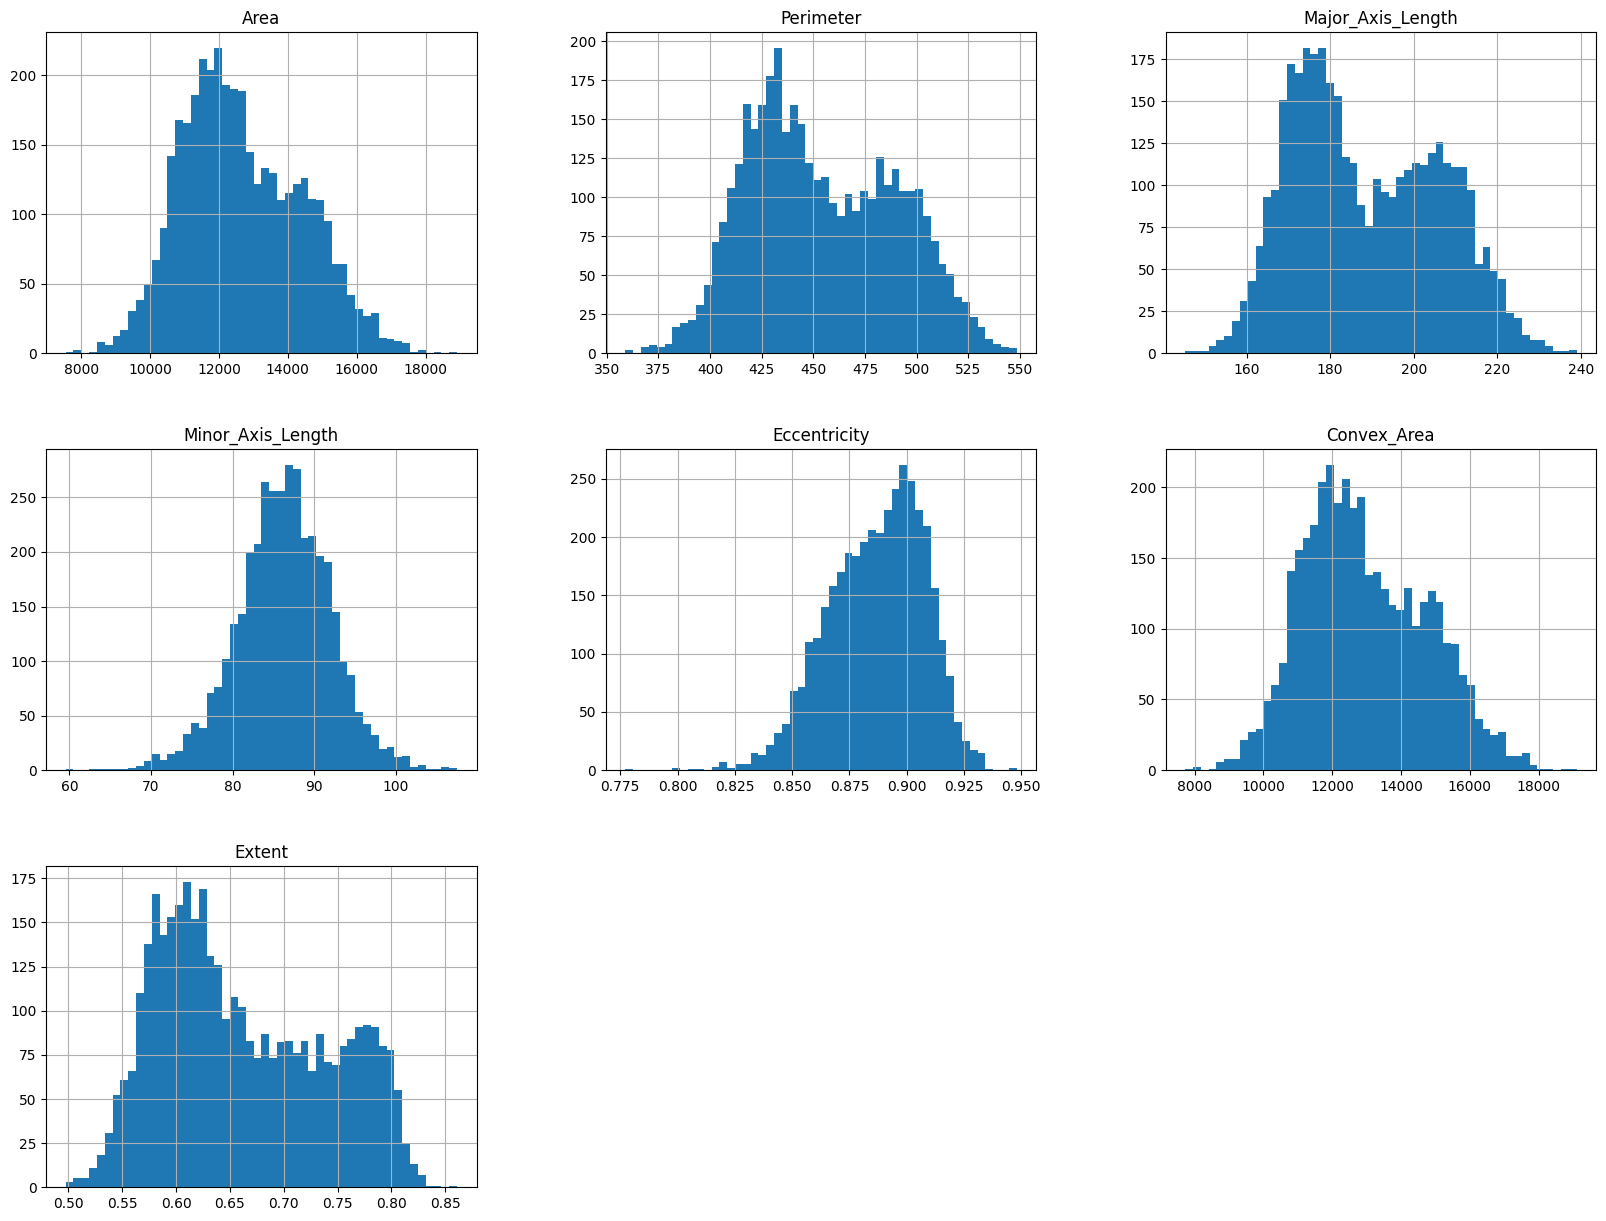

In [5]:
df.hist(bins=50, figsize=(20,15))
plt.show()

In [6]:
# Displays total counts for each unique label in the Class column
df['Class'].value_counts()

Class
Osmancik    2180
Cammeo      1630
Name: count, dtype: int64

C:\Users\rahna\AppData\Local\Temp\ipykernel_6416\2050935629.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Class', palette='Set2')


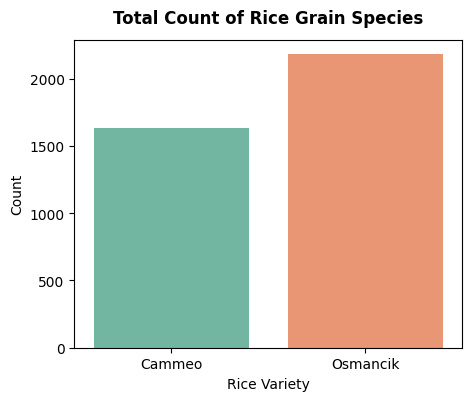

In [7]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='Class', palette='Set2')

plt.title('Total Count of Rice Grain Species', fontsize=12, pad=12, fontweight='bold')
plt.xlabel('Rice Variety')
plt.ylabel('Count')

plt.show()

## 2. Pre-Processing

In [8]:
X = df.drop(columns=['Class'])
y = df['Class']
# Convert text classes ('Cammeo', 'Osmancik') into 1s and 0s
y = y.map({'Osmancik': 0, 'Cammeo': 1})

## 3. Splitting the dataset into Training and Testing Sets

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% for testing, 80% for training
    random_state=42,    # Ensures you get the exact same split every time you run it
    stratify=y          # Maintains class balance in both splits
)

## 4. Scaling the features

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit the scaler ONLY on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data using the SAME scaler (do not re-fit!)
X_test_scaled = scaler.transform(X_test)

In [12]:
# Check if our feature scaling worked correctly
print(f"Training features shape: {X_train_scaled.shape}")
print(f"Testing features shape: {X_test_scaled.shape}")
print(f"Class distribution in training set:\n{y_train.value_counts(normalize=True)}")

Training features shape: (3048, 7)
Testing features shape: (762, 7)
Class distribution in training set:
Class
0    0.572178
1    0.427822
Name: proportion, dtype: float64
